In [319]:
import re
import pandas as pd
from typing import  Literal,List,Any
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.types import Command
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict, Annotated
from langchain_core.prompts.chat import ChatPromptTemplate
from langgraph.graph import START, StateGraph,END
from langgraph.prebuilt import create_react_agent
from pydantic import BaseModel, Field, field_validator
from langchain_core.messages import HumanMessage,AIMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [320]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

groq_model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY
)

In [321]:
import os
GROQ_API_KEY=os.getenv("GROQ_API_KEY")

In [322]:
import os
os.environ["GROQ_API_KEY"]=GROQ_API_KEY

In [323]:
groq_model.invoke("Hello")

AIMessage(content='Hello. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.028382631, 'prompt_time': 0.001716157, 'queue_time': 0.056400263, 'total_time': 0.030098788}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'finish_reason': 'stop', 'logprobs': None}, id='run-862c8afa-c6f1-4072-9cb9-f2703fdcec89-0', usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [324]:
class DateTimeModel(BaseModel):
    date: str = Field(description="Properly formatted date", pattern=r'^\d{2}-\d{2}-\d{4} \d{2}:\d{2}$')

    @field_validator("date")
    def check_format_date(cls, v):
        if not re.match(r'^\d{2}-\d{2}-\d{4} \d{2}:\d{2}$', v):  # Ensures 'DD-MM-YYYY HH:MM' format
            raise ValueError("The date should be in format 'DD-MM-YYYY HH:MM'")
        return v

In [325]:
class DateModel(BaseModel):
    date: str = Field(description="Properly formatted date", pattern=r'^\d{2}-\d{2}-\d{4}$')

    @field_validator("date")
    def check_format_date(cls, v):
        if not re.match(r'^\d{2}-\d{2}-\d{4}$', v):  # Ensures DD-MM-YYYY format
            raise ValueError("The date must be in the format 'DD-MM-YYYY'")
        return v

In [326]:
class IdentificationNumberModel(BaseModel):
    id: int = Field(description="Identification number (7 or 8 digits long)")
    @field_validator("id")
    def check_format_id(cls, v):
        if not re.match(r'^\d{7,8}$', str(v)):  # Convert to string before matching
            raise ValueError("The ID number should be a 7 or 8-digit number")
        return v

In [327]:
@tool
def check_availability_by_doctor(desired_date: str, doctor_name: Literal['kevin anderson','robert martinez','susan davis','daniel miller','sarah wilson','michael green','lisa brown','jane smith','emily johnson','john doe']):
    """
    Checking the database if we have availability for the specific doctor.
    The parameters should be mentioned by the user in the query.
    Format of desired_date is 'DD-MM-YYYY'.
    """
    df = pd.read_csv(r"../data/doctor_availability.csv")
    
    df['date_slot_time'] = df['date_slot'].apply(lambda input: input.split(' ')[-1])
    
    rows = list(df[(df['date_slot'].apply(lambda input: input.split(' ')[0]) == desired_date)&(df['doctor_name'] == doctor_name)&(df['is_available'] == True)]['date_slot_time'])

    if len(rows) == 0:
        output = "No availability in the entire day"
    else:
        output = f'This availability for {desired_date}\n'
        output += "Available slots: " + ', '.join(rows)

    return output

In [328]:
# Example usage:
date_instance = "03-09-2026"
print(date_instance)

03-09-2026


In [329]:
print(check_availability_by_doctor.invoke({"desired_date": date_instance, "doctor_name": "kevin anderson"}))

This availability for 03-09-2026
Available slots: 08:00, 08:30, 11:30, 12:00, 12:30, 13:00, 14:00, 14:30, 15:00, 15:30, 16:00, 16:30


In [330]:
@tool
def check_availability_by_specialization(desired_date: str, specialization: Literal["general_dentist", "cosmetic_dentist", "prosthodontist", "pediatric_dentist","emergency_dentist","oral_surgeon","orthodontist"]):
    """
    Checking the database if we have availability for the specific specialization.
    The parameters should be mentioned by the user in the query.
    Format of desired_date is 'DD-MM-YYYY'.
    """
    df = pd.read_csv(r"../data/doctor_availability.csv")
    df['date_slot_time'] = df['date_slot'].apply(lambda input: input.split(' ')[-1])
    rows = df[(df['date_slot'].apply(lambda input: input.split(' ')[0]) == desired_date) & (df['specialization'].str.contains(specialization, case=False, na=False)) & (df['is_available'] == True)].groupby(['specialization', 'doctor_name'])['date_slot_time'].apply(list).reset_index(name='available_slots')

    if len(rows) == 0:
        output = "No availability in the entire day"
    else:
        def convert_to_am_pm(time_str):
            time_str = str(time_str)
            hours, minutes = map(int, time_str.split(":"))
            period = "AM" if hours < 12 else "PM"
            hours = hours % 12 or 12
            return f"{hours}:{minutes:02d} {period}"
            
        output = f'This availability for {desired_date}\n'
        for row in rows.values:
            output += row[1] + ". Available slots: \n" + ', \n'.join([convert_to_am_pm(value) for value in row[2]])+'\n'

    return output

In [331]:
# Example usage:
date_instance = "03-09-2026"
print(date_instance)

03-09-2026


In [332]:
print(check_availability_by_specialization.invoke({"desired_date": date_instance, "specialization": "orthodontist"}))

This availability for 03-09-2026
kevin anderson. Available slots: 
8:00 AM, 
8:30 AM, 
11:30 AM, 
12:00 PM, 
12:30 PM, 
1:00 PM, 
2:00 PM, 
2:30 PM, 
3:00 PM, 
3:30 PM, 
4:00 PM, 
4:30 PM



In [333]:
@tool
def cancel_appointment(date: str, id_number: Any, doctor_name: str):
    """
    Canceling an appointment.
    The parameters MUST be mentioned by the user in the query.
    Format of date is 'DD-MM-YYYY HH:MM'.
    """
    df = pd.read_csv(r"../data/doctor_availability.csv")
    case_to_remove = df[(df['date_slot'] == date)&(df['patient_to_attend'] == float(id_number))&(df['doctor_name'].str.contains(doctor_name, case=False, na=False))]
    if len(case_to_remove) == 0:
        return "You don´t have any appointment with that specifications"
    else:
        df.loc[(df['date_slot'] == date) & (df['patient_to_attend'] == float(id_number)) & (df['doctor_name'].str.contains(doctor_name, case=False, na=False)), ['is_available', 'patient_to_attend']] = [True, None]
        df.to_csv(f"../data/doctor_availability.csv", index = False)

        return "Successfully cancelled"

In [334]:
print(cancel_appointment)

name='cancel_appointment' description="Canceling an appointment.\nThe parameters MUST be mentioned by the user in the query.\nFormat of date is 'DD-MM-YYYY HH:MM'." args_schema=<class 'langchain_core.utils.pydantic.cancel_appointment'> func=<function cancel_appointment at 0x0000012F17C87CE0>


In [335]:
Date = "07-08-2026 08:30"
Date

'07-08-2026 08:30'

In [336]:
IDNumber = 1000097
IDNumber

1000097

In [337]:
print(cancel_appointment.invoke({"date": Date,"id_number":IDNumber,"doctor_name":"john doe"}))

You don´t have any appointment with that specifications


In [338]:
@tool
def set_appointment(desired_date: str, id_number: Any, doctor_name: str):
    """
    Set appointment or slot with the doctor.
    The parameters MUST be mentioned by the user in the query.
    Format of desired_date is 'DD-MM-YYYY HH:MM'.
    """
    df = pd.read_csv(r"../data/doctor_availability.csv")
   
    from datetime import datetime
    def convert_datetime_format(dt_str):
        # Allow multiple formats in case the LLM generates a different one
        try:
            dt = datetime.strptime(dt_str, "%d-%m-%Y %H:%M")
        except ValueError:
            try:
                dt = datetime.strptime(dt_str, "%Y-%m-%d %H:%M")
            except ValueError:
                return dt_str # return as is if cannot string parse
        
        return dt.strftime("%d-%m-%Y %#H.%M") if os.name == 'nt' else dt.strftime("%d-%m-%Y %-H.%M")
    
    formatted_date = convert_datetime_format(desired_date)
    case = df[(df['date_slot'] == formatted_date)&(df['doctor_name'].str.contains(doctor_name, case=False, na=False))&(df['is_available'] == True)]
    if len(case) == 0:
        return "No available appointments for that particular case"
    else:
        df.loc[(df['date_slot'] == formatted_date)&(df['doctor_name'].str.contains(doctor_name, case=False, na=False)) & (df['is_available'] == True), ['is_available','patient_to_attend']] = [False, float(id_number)]
        df.to_csv(f"../data/doctor_availability.csv", index = False)

        return "Succesfully done"

In [339]:
Date = "07-08-2026 08:30"
Date

'07-08-2026 08:30'

In [340]:
IDNumber = 1000097
IDNumber

1000097

In [341]:
print(
    cancel_appointment.invoke({
        "date": "05-08-2026 08:30",
        "id_number": 1000097,
        "doctor_name": "john doe"
    })
)

You don´t have any appointment with that specifications


In [342]:
@tool
def reschedule_appointment(old_date: str, new_date: str, id_number: Any, doctor_name: str):
    """
    Rescheduling an appointment.
    The parameters MUST be mentioned by the user in the query.
    Format of old_date and new_date is 'DD-MM-YYYY HH:MM'.
    """
    df = pd.read_csv(r"../data/doctor_availability.csv")
    
    from datetime import datetime
    def convert_datetime_format(dt_str):
        try:
            dt = datetime.strptime(dt_str, "%d-%m-%Y %H:%M")
        except ValueError:
            try:
                dt = datetime.strptime(dt_str, "%Y-%m-%d %H:%M")
            except ValueError:
                return dt_str
        return dt.strftime("%d-%m-%Y %#H.%M") if os.name == 'nt' else dt.strftime("%d-%m-%Y %-H.%M")
        
    formatted_new_date = convert_datetime_format(new_date)
    
    available_for_desired_date = df[(df['date_slot'] == formatted_new_date)&(df['is_available'] == True)&(df['doctor_name'].str.contains(doctor_name, case=False, na=False))]
    if len(available_for_desired_date) == 0:
        return "Not available slots in the desired period"
    else:
        cancel_appointment.invoke({'date':old_date, 'id_number':id_number, 'doctor_name':doctor_name})
        set_appointment.invoke({'desired_date':new_date, 'id_number': id_number, 'doctor_name': doctor_name})
        return "Successfully rescheduled for the desired time"

In [343]:
Old_Date_Time = "05-08-2026 08:30"
Old_Date_Time

'05-08-2026 08:30'

In [344]:
New_Date_Time = "28-03-2026 14:30"
New_Date_Time

'28-03-2026 14:30'

In [345]:
IDNumber = 1000082
IDNumber

1000082

In [346]:
print(reschedule_appointment.invoke({"old_date": Old_Date_Time,"new_date": New_Date_Time,"id_number":IDNumber, "doctor_name": "kevin anderson"}))

Not available slots in the desired period


In [347]:
class Router(TypedDict):
    next: Literal["information_node","booking_node","FINISH"]
    reasoning: str

In [348]:
class AgentState(TypedDict):
    messages: Annotated[list[Any], add_messages]
    id_number: Any
    next:str
    query: str
    current_reasoning: str

In [349]:
members_dict = {'information_node':'specialized agent to provide information related to availability of doctors or any FAQs related to hospital.','booking_node':'specialized agent to only to book, cancel or reschedule appointment'}

In [350]:
members_dict

{'information_node': 'specialized agent to provide information related to availability of doctors or any FAQs related to hospital.',
 'booking_node': 'specialized agent to only to book, cancel or reschedule appointment'}

In [351]:
options = list(members_dict.keys()) + ["FINISH"]

In [352]:
options

['information_node', 'booking_node', 'FINISH']

In [353]:
worker_info = '\n\n'.join([f'WORKER: {member} \nDESCRIPTION: {description}' for member, description in members_dict.items()]) + '\n\nWORKER: FINISH \nDESCRIPTION: If User Query is answered and route to Finished'

In [354]:
print(worker_info)

WORKER: information_node 
DESCRIPTION: specialized agent to provide information related to availability of doctors or any FAQs related to hospital.

WORKER: booking_node 
DESCRIPTION: specialized agent to only to book, cancel or reschedule appointment

WORKER: FINISH 
DESCRIPTION: If User Query is answered and route to Finished


In [355]:
system_prompt = (
    "You are a supervisor tasked with managing a conversation between following workers. "
    "### SPECIALIZED ASSISTANT:\n"
    f"{worker_info}\n\n"
    "Your primary role is to help the user make an appointment with the doctor and provide updates on FAQs and doctor's availability. "
    "If a customer requests to know the availability of a doctor or to book, reschedule, or cancel an appointment, "
    "delegate the task to the appropriate specialized workers. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
    "UTILIZE last conversation to assess if the conversation should end you answered the query, then route to FINISH "
     )

In [356]:
print(system_prompt)

You are a supervisor tasked with managing a conversation between following workers. ### SPECIALIZED ASSISTANT:
WORKER: information_node 
DESCRIPTION: specialized agent to provide information related to availability of doctors or any FAQs related to hospital.

WORKER: booking_node 
DESCRIPTION: specialized agent to only to book, cancel or reschedule appointment

WORKER: FINISH 
DESCRIPTION: If User Query is answered and route to Finished

Your primary role is to help the user make an appointment with the doctor and provide updates on FAQs and doctor's availability. If a customer requests to know the availability of a doctor or to book, reschedule, or cancel an appointment, delegate the task to the appropriate specialized workers. Given the following user request, respond with the worker to act next. Each worker will perform a task and respond with their results and status. When finished, respond with FINISH.UTILIZE last conversation to assess if the conversation should end you answered 

In [357]:
def supervisor_node(state:AgentState) -> Command[Literal['information_node', 'booking_node', '__end__']]:
    print("**************************below is my state right after entering****************************")
    print(state)
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"user's identification number is {state['id_number']}"},
    ] + state["messages"][-3:]
    
    print("***********************this is my message*****************************************")
    print(messages)
    
    # query = state['messages'][-1].content if state["messages"] else ""
    query = ''
    if len(state['messages']) == 1:
        query = state['messages'][0].content
      
    print("************below is my query********************")    
    print(query)
    
    response = groq_model.with_structured_output(Router).invoke(messages)
    
    goto = response["next"]
    
    print("********************************this is my goto*************************")
    print(goto)
    
    print("********************************")
    print(response["reasoning"])
          
    if goto == "FINISH":
        goto = END
        
    print("**************************below is my state****************************")
    print(state)
    
    if query:
        return Command(goto=goto, update={'next': goto, 
                                          'query': query, 
                                          'current_reasoning': response["reasoning"],
                                          'messages': [HumanMessage(content=f"user's identification number is {state['id_number']}")]
                        })
    return Command(goto=goto, update={'next': goto, 
                                      'current_reasoning': response["reasoning"]}
                   )

In [358]:
def information_node(state:AgentState) -> Command[Literal['supervisor']]:
    print("*****************called information node************")
    
    system_prompt = "You are specialized agent to provide information related to availability of doctors or any FAQs related to hospital based on the query. You have access to the tool.\n Make sure to ask user politely if you need any further information to execute the tool.\n For your information, Always consider current year is 2026."
    
    system_prompt = ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    system_prompt
                ),
                (
                    "placeholder", 
                    "{messages}"
                ),
            ]
        )
    
    information_agent = create_react_agent(
    model=groq_model,
    tools=[check_availability_by_doctor, check_availability_by_specialization],
    prompt=system_prompt
)
    
    result = information_agent.invoke({"messages": state["messages"][-3:]})
    
    return Command(
        update={
            "messages": state["messages"] + [
                AIMessage(content=result["messages"][-1].content, name="information_node")
                #HumanMessage(content=result["messages"][-1].content, name="information_node")
            ]
        },
        goto="supervisor",
    )

In [359]:
def booking_node(state:AgentState) ->  Command[Literal['supervisor']]:
    
    print("*****************called booking node************")
    
    system_prompt = "You are specialized agent to set, cancel or reschedule appointment based on the query. You have access to the tool.\n Make sure to ask user politely if you need any further information to execute the tool.\n For your information, Always consider current year is 2026."
    
    system_prompt = ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    system_prompt
                ),
                (
                    "placeholder", 
                    "{messages}"
                ),
            ]
        )
    booking_agent = create_react_agent(model=groq_model,tools=[set_appointment,cancel_appointment,reschedule_appointment],prompt=system_prompt)

    result = booking_agent.invoke(state)
    
    return Command(
        update={
            "messages": state["messages"] + [
                AIMessage(content=result["messages"][-1].content, name="booking_node")
                #HumanMessage(content=result["messages"][-1].content, name="booking_node")
            ]
        },
        goto="supervisor",
    )

In [360]:
graph = StateGraph(AgentState)

In [361]:
graph.add_node("supervisor", supervisor_node)

In [362]:
graph.add_node("information_node", information_node)

In [363]:
graph.add_node("booking_node", booking_node)

In [364]:
graph.add_edge(START, "supervisor")

In [365]:
app = graph.compile()

In [366]:
import langgraph

graph = app.get_graph()
print(graph)

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=<class 'langchain_core.utils.pydantic.LangGraphInput'>, metadata=None), 'supervisor': Node(id='supervisor', name='supervisor', data=supervisor(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), 'information_node': Node(id='information_node', name='information_node', data=information_node(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), 'booking_node': Node(id='booking_node', name='booking_node', data=booking_node(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=<class 'langchain_core.utils.pydantic.LangGraphOutput'>, metadata=None)}, edges=[Edge(source='__start__', target='supervisor', data=None, conditional=False), Edge(source='supervisor', target='information_node', data=None, conditional=True), Edg

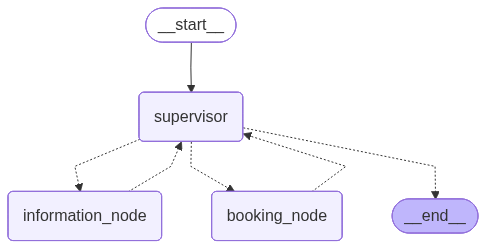

In [367]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [368]:
inputs = [
        HumanMessage(content='can you check and make a booking if general dentist available on 8 August 2026 at 8 PM?')
    ]

In [369]:
state = {'messages': inputs,'id_number':10232303}

In [370]:
result = app.invoke(state)

**************************below is my state right after entering****************************
{'messages': [HumanMessage(content='can you check and make a booking if general dentist available on 8 August 2026 at 8 PM?', additional_kwargs={}, response_metadata={}, id='5382bbfd-42cd-4869-8908-ce48b074ba54')], 'id_number': 10232303}
***********************this is my message*****************************************
[{'role': 'system', 'content': "You are a supervisor tasked with managing a conversation between following workers. ### SPECIALIZED ASSISTANT:\nWORKER: information_node \nDESCRIPTION: specialized agent to provide information related to availability of doctors or any FAQs related to hospital.\n\nWORKER: booking_node \nDESCRIPTION: specialized agent to only to book, cancel or reschedule appointment\n\nWORKER: FINISH \nDESCRIPTION: If User Query is answered and route to Finished\n\nYour primary role is to help the user make an appointment with the doctor and provide updates on FAQs 

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01jcwej3c8e47vend3f8k0sxb9` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99521, Requested 679. Please try again in 2m52.8s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
result["messages"][-1].content